In [1]:
if 'google.colab' in str(get_ipython()):
    print("Downloading Code to Colab Environment")
    !wget https://www.dropbox.com/sh/2am8d2yn4xrzk9i/AAAiJEQuwzAysEe6jNUGuCH4a?dl=1 -O module-code.zip -q --show-progress
    !unzip -qq module-code.zip
    !pip install --upgrade opencv-contrib-python
else:
    pass

In [2]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import Image

plt.rcParams['image.cmap'] = 'gray'

inputSize = (256, 256)

# East model for text-detection
textDetectorEAST = cv2.dnn_TextDetectionModel_EAST("./resources/frozen_east_text_detection.pb")

# Set the Detection Confidence Threshold and NMS threshold
conf_thresh = 0.8
nms_thresh = 0.4

textDetectorEAST.setConfidenceThreshold(conf_thresh).setNMSThreshold(nms_thresh)
textDetectorEAST.setInputParams(1.0, inputSize, (123.68, 116.78, 103.94), True)

# DB model for text-detection based on resnet50
textDetectorDB50 = cv2.dnn_TextDetectionModel_DB("./resources/DB_TD500_resnet50.onnx")
# DB model for text-detection based on resnet18
textDetectorDB18 = cv2.dnn_TextDetectionModel_DB("./resources/DB_TD500_resnet18.onnx")

# Set threshold for Binary Map creation and polygon detection
bin_thresh = 0.3
poly_thresh = 0.5

mean = (122.67891434, 116.66876762, 104.00698793)

textDetectorDB18.setBinaryThreshold(bin_thresh).setPolygonThreshold(poly_thresh)
textDetectorDB18.setInputParams(1.0/255, inputSize, mean, True)

textDetectorDB50.setBinaryThreshold(bin_thresh).setPolygonThreshold(poly_thresh)
textDetectorDB50.setInputParams(1.0/255, inputSize, mean, True)

def detectTextAll(image):
    """Performs each type of text detection over an image and displays all results side by side."""
    # Making copies of the original image
    imEAST = image.copy()
    imDB18 = image.copy()
    imDB50 = image.copy()

    # Use each text detector to detect the presence of text in the image
    boxesEAST, confsEAST = textDetectorEAST.detect(image)
    boxesDB18, confsDB18 = textDetectorDB18.detect(image)
    boxesDB50, confsDB50 = textDetectorDB50.detect(image)

    # Draw the bounding boxes onto the respective copies of the original image.
    cv2.polylines(imEAST, boxesEAST, True, (255, 0, 255), 4)
    cv2.polylines(imDB18, boxesDB18, True, (255, 0, 255), 4)
    cv2.polylines(imDB50, boxesDB50, True, (255, 0, 255), 4)

    output = cv2.hconcat([image, imEAST, imDB18, imDB50])
    # Display the output image
    plt.figure(figsize=(20,10))
    plt.imshow(output[:, :, ::-1]); plt.title('Original | EAST | DB18 | DB50')


ModuleNotFoundError: No module named 'matplotlib'

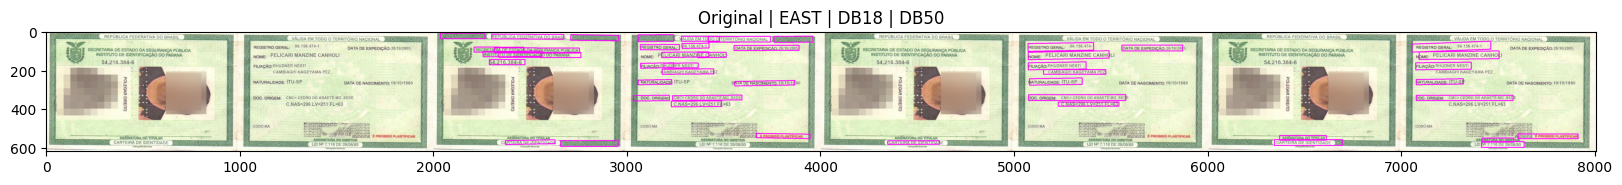

In [ ]:
img1 = cv2.imread('AP1/Images/00018413_in.jpg')
detectTextAll(img1)

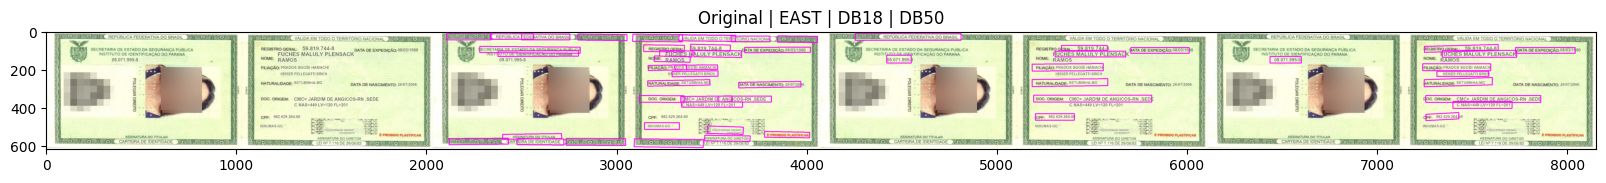

In [ ]:
img2 = cv2.imread('AP1/Images/00018414_in.jpg')
detectTextAll(img2)

Avaliando o tempo de execução por 10 iterações...
Iteração 1/10 concluída.
Iteração 2/10 concluída.
Iteração 3/10 concluída.
Iteração 4/10 concluída.
Iteração 5/10 concluída.
Iteração 6/10 concluída.
Iteração 7/10 concluída.
Iteração 8/10 concluída.
Iteração 9/10 concluída.
Iteração 10/10 concluída.

Tempo de execução médio (segundos):
  EAST: 0.1594 +/- 0.0026
  DB18: 0.1151 +/- 0.0019
  DB50: 0.2406 +/- 0.0069


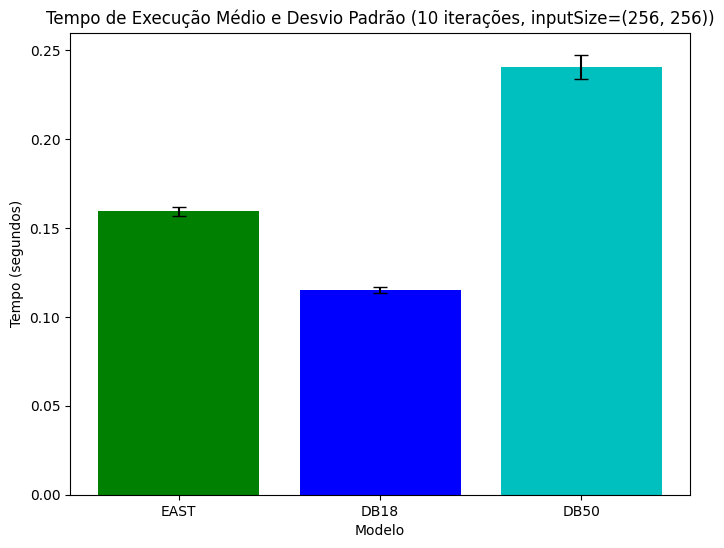

In [ ]:
iterations = 10 

timesEAST = []
timesDB18 = []
timesDB50 = []

print(f"Avaliando o tempo de execução por {iterations} iterações...")

for i in range(iterations):
    # Medir tempo para EAST
    start_time_east = time.time()
    result_east = textDetectorEAST.detect(img2)
    end_time_east = time.time()
    timesEAST.append(end_time_east - start_time_east)

    # Medir tempo para DB18
    start_time_db18 = time.time()
    result_db18 = textDetectorDB18.detect(img2)
    end_time_db18 = time.time()
    timesDB18.append(end_time_db18 - start_time_db18)

    # Medir tempo para DB50
    start_time_db50 = time.time()
    result_db50 = textDetectorDB50.detect(img2)
    end_time_db50 = time.time()
    timesDB50.append(end_time_db50 - start_time_db50)

    print(f"Iteração {i+1}/{iterations} concluída.")

avgEAST = np.mean(timesEAST)
stdEAST = np.std(timesEAST)

avgDB18 = np.mean(timesDB18)
stdDB18 = np.std(timesDB18)

avgDB50 = np.mean(timesDB50)
stdDB50 = np.std(timesDB50)

print("\nTempo de execução médio (segundos):")
print(f"  EAST: {avgEAST:.4f} +/- {stdEAST:.4f}")
print(f"  DB18: {avgDB18:.4f} +/- {stdDB18:.4f}")
print(f"  DB50: {avgDB50:.4f} +/- {stdDB50:.4f}")

labels = ['EAST', 'DB18', 'DB50']
averages = [avgEAST, avgDB18, avgDB50]
std_devs = [stdEAST, stdDB18, stdDB50]

plt.figure(figsize=(8, 6))
plt.bar(labels, averages, yerr=std_devs, capsize=5, color=['g', 'b', 'c'])
plt.ylabel("Tempo (segundos)")
plt.xlabel("Modelo")
plt.title(f"Tempo de Execução Médio e Desvio Padrão ({iterations} iterações, inputSize={inputSize})")
plt.show()

Ao diminuir o inputSize para 256, observa-se uma melhora significativa no desempenho.